<a href="https://colab.research.google.com/github/Holardiplenty123/Patient-No-Show-Prediction-Machine-Learning-Project/blob/main/No_Show__Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospitals and clinics face a significant operational and financial problem when patients book appointments but do not show up.

No-shows lead to:,
-  Idle doctors and staff,
- Wasted appointment slots that could have been given to other patients
- Longer waiting lists
- Direct revenue loss

Build a machine learning model that estimates the probability of a patient not showing up. This allows the hospital to reduce wasted resources, improve efficiency, and protect revenue.

In [ ]:
from google.colab import userdata
userdata.get('ML_Project')

'KGAT_b3a921467a92313538a845b0e692d7dc'

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joniarroba/noshowappointments")

print("Path to dataset files:", path)

100%|██████████| 2.40M/2.40M [00:00<00:00, 125MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/joniarroba/noshowappointments/versions/5


In [ ]:
path

'/root/.cache/kagglehub/datasets/joniarroba/noshowappointments/versions/5'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
import os

# List the contents of the directory to find the CSV file
file_name = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_file_path = os.path.join(path, file_name)

df = pd.read_csv(csv_file_path)

In [ ]:
df.head(10)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,No


In [ ]:
print(df.shape)


(110527, 14)


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None


In [ ]:
print(df['No-show'].value_counts(normalize=True))   # check imbalance
df.describe()

No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [ ]:
# Fix column names (optional but cleaner)
df.columns = df.columns.str.lower().str.replace('-', '_').str.replace(' ', '_')

In [ ]:
# Check missing values
print(df.isnull().sum())


patientid         0
appointmentid     0
gender            0
scheduledday      0
appointmentday    0
age               0
neighbourhood     0
scholarship       0
hipertension      0
diabetes          0
alcoholism        0
handcap           0
sms_received      0
no_show           0
dtype: int64


In [ ]:
# Remove rows with Age < 0 (there are a few bad values)
df = df[df['age'] >= 0]


In [ ]:
# Drop columns we don’t need for modeling
df = df.drop(['patientid', 'appointmentid'], axis=1)

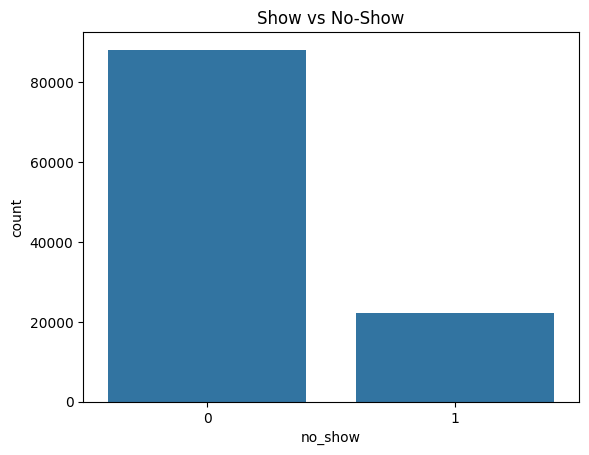

In [ ]:
sns.countplot(x='no_show', data=df)
plt.title('Show vs No-Show')
plt.show()

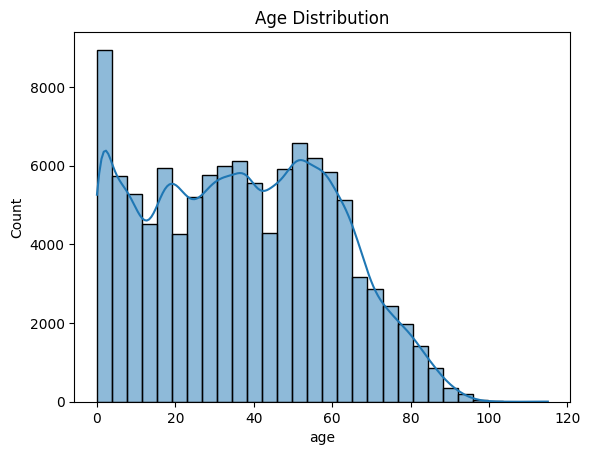

In [ ]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

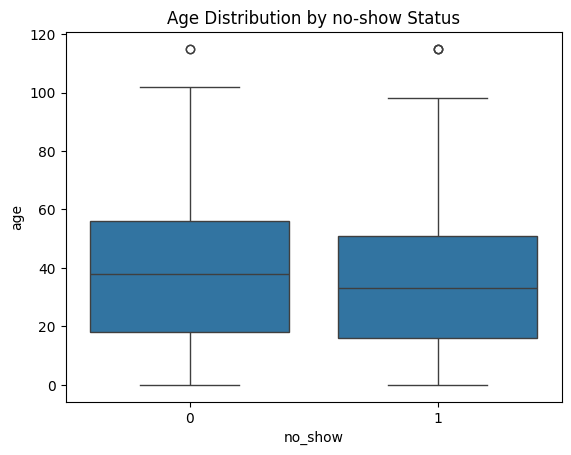

In [ ]:
sns.boxplot(x='no_show', y='age', data=df)
plt.title('Age Distribution by no-show Status')
plt.show()

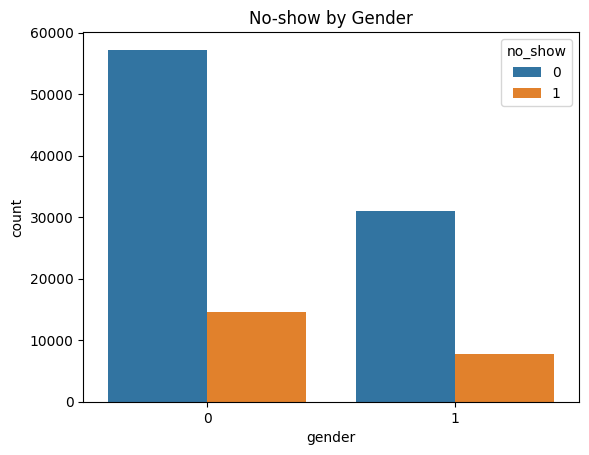

In [ ]:
sns.countplot(x='gender', hue='no_show', data=df)
plt.title('No-show by Gender')
plt.show()

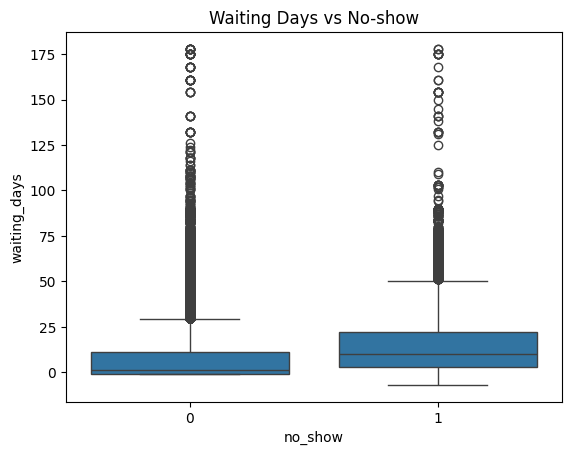

In [ ]:
sns.boxplot(x='no_show', y='waiting_days', data=df)
plt.title('Waiting Days vs No-show')
plt.show()

In [ ]:
# Convert dates
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])


In [ ]:
# Create waiting days feature (very useful!)
df['waiting_days'] = (df['appointmentday'] - df['scheduledday']).dt.days

In [ ]:
# Encode target
df['no_show'] = df['no_show'].map({'No': 0, 'Yes': 1})

In [ ]:
# Encode Gender
df['gender'] = df['gender'].map({'F': 0, 'M': 1})

In [ ]:
# Select features (start simple)
features = ['gender', 'age', 'scholarship', 'hipertension', 'diabetes',
            'alcoholism', 'handcap', 'sms_received', 'waiting_days']

X = df[features]
y = df['no_show']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)          # trees don’t need scaling
y_pred_rf = rf.predict(X_test)

# 3. K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== KNN ===")
print(classification_report(y_test, y_pred_knn))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.36      0.01      0.03      4464

    accuracy                           0.80     22106
   macro avg       0.58      0.50      0.46     22106
weighted avg       0.71      0.80      0.71     22106

[[17523   119]
 [ 4398    66]]

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     17642
           1       0.35      0.20      0.26      4464

    accuracy                           0.76     22106
   macro avg       0.59      0.55      0.56     22106
weighted avg       0.72      0.76      0.74     22106


=== KNN ===
              precision    recall  f1-score   support

           0       0.81      0.91      0.86     17642
           1       0.33      0.18      0.23      4464

    accuracy                           0.76     22106
   macro avg       0.57      0.54

In [ ]:
# Logistic Regression with balanced class weight
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)
y_pred_lr_bal = lr_balanced.predict(X_test_scaled)

print("=== Logistic Regression (Balanced) ===")
print(classification_report(y_test, y_pred_lr_bal))
print(confusion_matrix(y_test, y_pred_lr_bal))

# Random Forest with balanced class weight
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
y_pred_rf_bal = rf_balanced.predict(X_test)

print("\n=== Random Forest (Balanced) ===")
print(classification_report(y_test, y_pred_rf_bal))
print(confusion_matrix(y_test, y_pred_rf_bal))

=== Logistic Regression (Balanced) ===
              precision    recall  f1-score   support

           0       0.86      0.69      0.77     17642
           1       0.32      0.57      0.41      4464

    accuracy                           0.67     22106
   macro avg       0.59      0.63      0.59     22106
weighted avg       0.75      0.67      0.70     22106

[[12237  5405]
 [ 1915  2549]]

=== Random Forest (Balanced) ===
              precision    recall  f1-score   support

           0       0.84      0.77      0.80     17642
           1       0.31      0.42      0.36      4464

    accuracy                           0.70     22106
   macro avg       0.58      0.59      0.58     22106
weighted avg       0.73      0.70      0.71     22106

[[13534  4108]
 [ 2597  1867]]


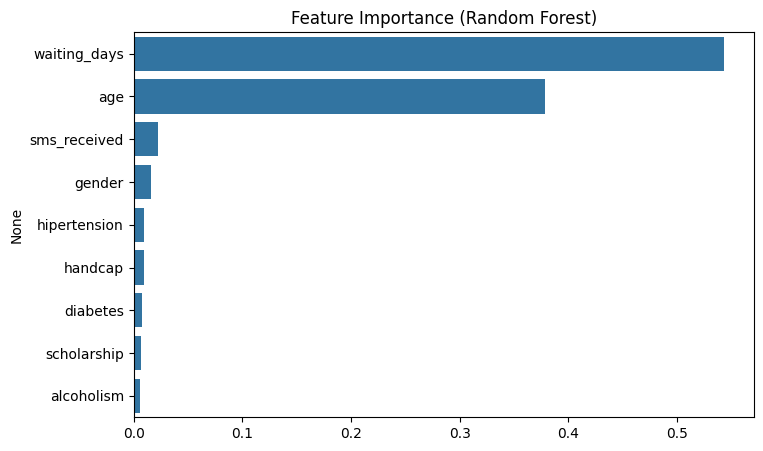

waiting_days    0.543528
age             0.378202
sms_received    0.022668
gender          0.015996
hipertension    0.009343
handcap         0.009176
diabetes        0.008037
scholarship     0.007207
alcoholism      0.005844
dtype: float64


In [ ]:
importances = pd.Series(rf_balanced.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance (Random Forest)')
plt.show()

print(importances)